## 1. Import Libraries

In [1]:
import xml.etree.ElementTree as ETimport pandas as pdimport numpy as npfrom datetime import datetime, timedeltaimport requestsfrom time import sleepimport osimport globimport refrom tqdm import tqdmimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsfrom scipy.cluster.hierarchy import fcluster, linkagefrom scipy.spatial.distance import cdistimport pytzimport warningswarnings.filterwarnings('ignore')plt.style.use('seaborn-v0_8-whitegrid')sns.set_palette("husl")print("✅ Libraries imported!")

✅ Libraries imported!


## 2. Configuration

In [2]:
# File pathsXML_FILE_PATH = r"C:\Project\Apple Health Data\data\apple_health_export\export_cleaned.xml"GPX_FOLDER = r"C:\Project\Apple Health Data\data\apple_health_export\workout-routes"OUTPUT_DIR = r"C:\Project\Apple Health Data\output"os.makedirs(OUTPUT_DIR, exist_ok=True)# Heart Rate typesHR_TYPES = [    "HKQuantityTypeIdentifierHeartRate",    "HKQuantityTypeIdentifierRestingHeartRate",    "HKQuantityTypeIdentifierWalkingHeartRateAverage"]print(f"📁 XML File: {XML_FILE_PATH}")print(f"📁 GPX Folder: {GPX_FOLDER}")print(f"📁 Output: {OUTPUT_DIR}")

📁 XML File: C:\Project\Apple Health Data\data\apple_health_export\export_cleaned.xml
📁 GPX Folder: C:\Project\Apple Health Data\data\apple_health_export\workout-routes
📁 Output: C:\Project\Apple Health Data\output


## 3. Extract Heart Rate Data

In [3]:
def extract_heart_rate_data(xml_path):    """Extract HR data with streaming parser for memory efficiency."""    records = []    record_count = 0        print("⏳ Extracting Heart Rate data...")    print("=" * 60)        for event, elem in ET.iterparse(xml_path, events=('end',)):        if elem.tag == 'Record':            record_count += 1            record_type = elem.get('type', '')                        if record_type in HR_TYPES:                records.append({                    'type': record_type.replace('HKQuantityTypeIdentifier', ''),                    'sourceName': elem.get('sourceName', ''),                    'value': float(elem.get('value', 0)),                    'unit': elem.get('unit', ''),                    'startDate': elem.get('startDate', ''),                    'endDate': elem.get('endDate', ''),                })                        elem.clear()                        if record_count % 500000 == 0:                print(f"  Scanned {record_count:,} records... Found {len(records):,} HR records")        print("=" * 60)    print(f"✅ Extracted {len(records):,} Heart Rate records")        df = pd.DataFrame(records)        if len(df) > 0:        df['startDate'] = pd.to_datetime(            df['startDate'].str.replace(r' [+-]\d{4}$', '', regex=True)        )        df['endDate'] = pd.to_datetime(            df['endDate'].str.replace(r' [+-]\d{4}$', '', regex=True)        )        df = df.sort_values('startDate').reset_index(drop=True)        return dfhr_df = extract_heart_rate_data(XML_FILE_PATH)

⏳ Extracting Heart Rate data...
  Scanned 500,000 records... Found 356,862 HR records
  Scanned 1,000,000 records... Found 356,862 HR records
  Scanned 1,500,000 records... Found 356,862 HR records
  Scanned 2,000,000 records... Found 356,862 HR records
  Scanned 2,500,000 records... Found 356,862 HR records
✅ Extracted 360,282 Heart Rate records


## 4. Extract Workout Data

In [4]:
def extract_workout_data(xml_path):    """Extract workout sessions with metadata."""    workouts = []        print("⏳ Extracting Workout data...")        for event, elem in ET.iterparse(xml_path, events=('end',)):        if elem.tag == 'Workout':            workout = {                'workoutType': elem.get('workoutActivityType', '').replace('HKWorkoutActivityType', ''),                'duration': float(elem.get('duration', 0)),                'durationUnit': elem.get('durationUnit', ''),                'totalDistance': float(elem.get('totalDistance', 0) or 0),                'totalDistanceUnit': elem.get('totalDistanceUnit', ''),                'totalEnergyBurned': float(elem.get('totalEnergyBurned', 0) or 0),                'sourceName': elem.get('sourceName', ''),                'startDate': elem.get('startDate', ''),                'endDate': elem.get('endDate', ''),            }            workouts.append(workout)            elem.clear()        print(f"✅ Extracted {len(workouts):,} Workout records")        df = pd.DataFrame(workouts)        if len(df) > 0:        df['startDate'] = pd.to_datetime(            df['startDate'].str.replace(r' [+-]\d{4}$', '', regex=True)        )        df['endDate'] = pd.to_datetime(            df['endDate'].str.replace(r' [+-]\d{4}$', '', regex=True)        )        df = df.sort_values('startDate').reset_index(drop=True)        return dfworkouts_df = extract_workout_data(XML_FILE_PATH)

⏳ Extracting Workout data...
✅ Extracted 289 Workout records


## 5. Data Overview

In [5]:
print("📊 DATA SUMMARY")print("=" * 50)print(f"\n🫀 Heart Rate Data:")print(f"   Total records: {len(hr_df):,}")print(f"   Date range: {hr_df['startDate'].min()} → {hr_df['startDate'].max()}")print(f"   Types: {hr_df['type'].unique().tolist()}")print(f"\n🏃 Workout Data:")print(f"   Total workouts: {len(workouts_df):,}")print(f"   Date range: {workouts_df['startDate'].min()} → {workouts_df['startDate'].max()}")print(f"   Unique workout types: {workouts_df['workoutType'].nunique()}")print(f"\n📋 Top Workout Types:")print(workouts_df['workoutType'].value_counts())

📊 DATA SUMMARY

🫀 Heart Rate Data:
   Total records: 360,282
   Date range: 2017-11-27 09:47:34 → 2022-09-23 10:59:44
   Types: ['HeartRate', 'WalkingHeartRateAverage', 'RestingHeartRate']

🏃 Workout Data:
   Total workouts: 289
   Date range: 2017-12-29 12:00:25 → 2022-09-22 10:11:43
   Unique workout types: 5

📋 Top Workout Types:
workoutType
Walking    180
Rowing      93
Cycling     10
Running      5
Hiking       1
Name: count, dtype: int64


## 6. Parse GPX Files for GPS Data

In [6]:
def parse_gpx_files(gpx_folder):    print("⏳ Parsing GPX files...")    print("=" * 50)        gpx_files = glob.glob(os.path.join(gpx_folder, '*.gpx'))    print(f"📂 Found {len(gpx_files)} GPX files")        all_routes = []    all_trackpoints = []        for gpx_file in tqdm(gpx_files, desc="   Parsing"):        try:            tree = ET.parse(gpx_file)            root = tree.getroot()                        # Handle GPX namespace            ns = {'gpx': 'http://www.topografix.com/GPX/1/1'}                        filename = os.path.basename(gpx_file)                        # Extract all track points            points = []            for trkpt in root.findall('.//gpx:trkpt', ns):                lat = float(trkpt.get('lat'))                lon = float(trkpt.get('lon'))                                time_elem = trkpt.find('gpx:time', ns)                timestamp = pd.to_datetime(time_elem.text) if time_elem is not None else None                                # Get elevation if available                ele_elem = trkpt.find('gpx:ele', ns)                elevation = float(ele_elem.text) if ele_elem is not None else None                                point_data = {                    'filename': filename,                    'latitude': lat,                    'longitude': lon,                    'timestamp': timestamp,                    'elevation': elevation                }                points.append(point_data)                all_trackpoints.append(point_data)                        if points:                lats = [p['latitude'] for p in points]                lons = [p['longitude'] for p in points]                                all_routes.append({                    'filename': filename,                    'center_lat': np.mean(lats),                    'center_lon': np.mean(lons),                    'start_lat': lats[0],                    'start_lon': lons[0],                    'end_lat': lats[-1],                    'end_lon': lons[-1],                    'num_points': len(points),                    'start_time': points[0]['timestamp'],                    'end_time': points[-1]['timestamp'],                    'min_lat': min(lats),                    'max_lat': max(lats),                    'min_lon': min(lons),                    'max_lon': max(lons)                })                        except Exception as e:            print(f"   ⚠️ Error parsing {filename}: {e}")        routes_df = pd.DataFrame(all_routes)    trackpoints_df = pd.DataFrame(all_trackpoints)        print(f"\n✅ Parsed {len(routes_df)} routes")    print(f"✅ Total trackpoints: {len(trackpoints_df):,}")        return routes_df, trackpoints_dfroutes_df, trackpoints_df = parse_gpx_files(GPX_FOLDER)def parse_gpx_with_elevation(gpx_folder):    print("⏳ Parsing GPX files with elevation...")    print("=" * 50)        gpx_files = glob.glob(os.path.join(gpx_folder, '*.gpx'))    print(f"📂 Found {len(gpx_files)} GPX files")        all_routes = []        for gpx_file in tqdm(gpx_files, desc="   Parsing"):        try:            tree = ET.parse(gpx_file)            root = tree.getroot()            ns = {'gpx': 'http://www.topografix.com/GPX/1/1'}            filename = os.path.basename(gpx_file)                        points = []            elevations = []                        for trkpt in root.findall('.//gpx:trkpt', ns):                lat = float(trkpt.get('lat'))                lon = float(trkpt.get('lon'))                                time_elem = trkpt.find('gpx:time', ns)                timestamp = pd.to_datetime(time_elem.text) if time_elem is not None else None                                ele_elem = trkpt.find('gpx:ele', ns)                elevation = float(ele_elem.text) if ele_elem is not None else None                                points.append({'lat': lat, 'lon': lon, 'time': timestamp, 'ele': elevation})                if elevation is not None:                    elevations.append(elevation)                        if points:                lats = [p['lat'] for p in points]                lons = [p['lon'] for p in points]                                # Calculate elevation gain (sum of positive elevation changes)                elevation_gain = 0                elevation_loss = 0                if len(elevations) > 1:                    for i in range(1, len(elevations)):                        diff = elevations[i] - elevations[i-1]                        if diff > 0:                            elevation_gain += diff                        else:                            elevation_loss += abs(diff)                                all_routes.append({                    'filename': filename,                    'center_lat': np.mean(lats),                    'center_lon': np.mean(lons),                    'start_lat': lats[0],                    'start_lon': lons[0],                    'num_points': len(points),                    'start_time': points[0]['time'],                    'end_time': points[-1]['time'],                    'min_elevation': min(elevations) if elevations else None,                    'max_elevation': max(elevations) if elevations else None,                    'elevation_gain': round(elevation_gain, 1),                    'elevation_loss': round(elevation_loss, 1),                    'avg_elevation': round(np.mean(elevations), 1) if elevations else None                })                        except Exception as e:            pass        routes_df = pd.DataFrame(all_routes)    print(f"\n✅ Parsed {len(routes_df)} routes with elevation data")    print(f"   Routes with elevation: {routes_df['elevation_gain'].notna().sum()}")        return routes_dfroutes_df = parse_gpx_with_elevation(GPX_FOLDER)

⏳ Parsing GPX files...
📂 Found 177 GPX files


   Parsing: 100%|█████████████████████████████████████████████████████████████████████████████████| 177/177 [02:14<00:00,  1.32it/s]



✅ Parsed 177 routes
✅ Total trackpoints: 299,918
⏳ Parsing GPX files with elevation...
📂 Found 177 GPX files


   Parsing: 100%|█████████████████████████████████████████████████████████████████████████████████| 177/177 [02:04<00:00,  1.43it/s]


✅ Parsed 177 routes with elevation data
   Routes with elevation: 177


## 7. Cluster Workout Locations (distance threshold = 2km)

In [7]:
def cluster_locations(routes_df, distance_threshold_km=2):    print("📍 Clustering workout locations...")    print("=" * 50)        if len(routes_df) < 2:        print("   ⚠️ Not enough routes to cluster")        routes_df['location_cluster'] = 1        return routes_df        coords = routes_df[['center_lat', 'center_lon']].values        # Convert km to approximate degrees (1 degree ≈ 111km)    threshold_degrees = distance_threshold_km / 111        Z = linkage(coords, method='average')    routes_df['location_cluster'] = fcluster(Z, t=threshold_degrees, criterion='distance')        n_clusters = routes_df['location_cluster'].nunique()    print(f"✅ Found {n_clusters} distinct workout locations")        # Summarize each cluster    location_summary = routes_df.groupby('location_cluster').agg({        'center_lat': 'mean',        'center_lon': 'mean',        'filename': 'count',        'start_time': ['min', 'max']    }).round(4)    location_summary.columns = ['latitude', 'longitude', 'workout_count', 'first_visit', 'last_visit']    location_summary = location_summary.sort_values('workout_count', ascending=False)        print("\n🏃 Workout Locations Summary:")    print(location_summary)        return routes_df, location_summaryroutes_df, location_summary = cluster_locations(routes_df, distance_threshold_km=2.0)

📍 Clustering workout locations...
✅ Found 23 distinct workout locations

🏃 Workout Locations Summary:
                  latitude  longitude  workout_count  \
location_cluster                                       
5                 -35.0037   138.5959             76   
6                 -34.9233   138.6025             48   
15                 59.4384    24.7533             21   
4                 -34.9748   138.5972              4   
1                 -27.5588   153.0634              3   
3                 -34.9159   138.4921              2   
2                 -35.5186   138.7642              2   
18                 51.4760    -0.4573              2   
13                 59.3915    24.6677              2   
14                 59.4509    24.7330              2   
17                 51.4812    -0.4404              2   
22                 55.6868    12.5882              2   
7                 -34.9047   138.5910              1   
11                 59.3177    18.0525              1   
8 

## 8. Identify Location Names (Reverse Geocoding)

In [8]:
def reverse_geocode_locations(location_summary, timeout=10, zoom=16):    """    Reverse geocode cluster centers to get readable location names.        Args:        location_summary: DataFrame with latitude/longitude columns        timeout: Request timeout in seconds        zoom: Detail level (14=suburb/city, 16=street/park)        Returns:        dict: cluster_id -> location_name mapping    """    print("🌍 Reverse geocoding locations...")    print("=" * 50)        cluster_names = {}        for cluster_id in location_summary.index:        loc = location_summary.loc[cluster_id]                try:            url = "https://nominatim.openstreetmap.org/reverse"            params = {                'lat': loc['latitude'],                'lon': loc['longitude'],                'format': 'json',                'zoom': zoom            }            headers = {'User-Agent': 'AppleHealthAnalysis/1.0'}                        response = requests.get(url, params=params, headers=headers, timeout=timeout)            response.raise_for_status()  # Check HTTP errors            data = response.json()                        address = data.get('address', {})            name = (address.get('leisure') or                     address.get('park') or                    address.get('suburb') or                     address.get('city_district') or                    address.get('city') or                     address.get('town') or                    f"Location_{cluster_id}")                        cluster_names[cluster_id] = name            print(f"   Cluster {cluster_id} → {name}")            sleep(1)  # Rate limit                    except Exception as e:            cluster_names[cluster_id] = f"Location_{cluster_id}"            print(f"   Cluster {cluster_id} → ⚠️ Error: {e}")        print("=" * 50)    return cluster_names# Usage (giữ nguyên như code cũ)cluster_names = reverse_geocode_locations(location_summary)# Apply to dataframesroutes_df['location_name'] = routes_df['location_cluster'].astype('Int64').map(cluster_names)location_summary['location_name'] = location_summary.index.astype(int).map(cluster_names)print("\n📍 Final Location Mapping:")print(location_summary[['location_name', 'workout_count', 'latitude', 'longitude']])

🌍 Reverse geocoding locations...
   Cluster 5 → Panorama
   Cluster 6 → Adelaide
   Cluster 15 → Kesklinna linnaosa
   Cluster 4 → Westbourne Park
   Cluster 1 → Nathan
   Cluster 3 → Henley Beach
   Cluster 2 → Goolwa Beach
   Cluster 18 → Harmondsworth
   Cluster 13 → Mustamäe linnaosa
   Cluster 14 → Põhja-Tallinna linnaosa
   Cluster 17 → London Borough of Hillingdon
   Cluster 22 → Indre By
   Cluster 7 → North Adelaide
   Cluster 11 → Södermalm
   Cluster 8 → Wayville
   Cluster 12 → Norrmalm
   Cluster 9 → Walkerville
   Cluster 10 → Woodforde
   Cluster 16 → Kesklinna linnaosa
   Cluster 19 → South Kensington
   Cluster 20 → Lowfield Heath
   Cluster 21 → Twyford
   Cluster 23 → Sulzbach

📍 Final Location Mapping:
                                 location_name  workout_count  latitude  \
location_cluster                                                          
5                                     Panorama             76  -35.0037   
6                                     Adela

## 9. Link Workouts to HR Data

In [9]:
def link_workouts_to_hr(hr_df, workouts_df, routes_df):    """    Link HR records to workout sessions and their locations.    """    print("⏳ Linking HR data to workouts and locations...")    print("=" * 60)        hr_df = hr_df.copy()    hr_df['activity_context'] = 'resting'    hr_df['workout_type'] = None    hr_df['workout_id'] = None    hr_df['location_cluster'] = None        # Create workout lookup with location    workout_location = workouts_df.copy()        # Match routes to workouts by date    if 'start_time' in routes_df.columns:        routes_df['workout_date'] = pd.to_datetime(routes_df['start_time']).dt.date        workout_location['workout_date'] = workout_location['startDate'].dt.date                workout_location = workout_location.merge(            routes_df[['workout_date', 'location_cluster', 'center_lat', 'center_lon']].drop_duplicates(),            on='workout_date',            how='left'        )        # Tag HR records    tagged_count = 0    for idx, row in tqdm(workout_location.iterrows(), total=len(workout_location), desc="   Matching"):        mask = (hr_df['startDate'] >= row['startDate']) & (hr_df['startDate'] <= row['endDate'])        matches = mask.sum()                if matches > 0:            hr_df.loc[mask, 'activity_context'] = 'workout'            hr_df.loc[mask, 'workout_type'] = row['workoutType']            hr_df.loc[mask, 'workout_id'] = idx            if 'location_cluster' in row and pd.notna(row['location_cluster']):                hr_df.loc[mask, 'location_cluster'] = row['location_cluster']            tagged_count += matches        print("=" * 60)    print(f"✅ Tagged {tagged_count:,} HR records with workout context")    print(f"✅ HR records with location: {hr_df['location_cluster'].notna().sum():,}")    hr_df['location_name'] = hr_df['location_cluster'].astype('Int64').map(cluster_names)        return hr_dfhr_df = link_workouts_to_hr(hr_df, workouts_df, routes_df)

⏳ Linking HR data to workouts and locations...


   Matching: 100%|███████████████████████████████████████████████████████████████████████████████| 413/413 [00:02<00:00, 180.99it/s]


✅ Tagged 12,856 HR records with workout context
✅ HR records with location: 5,073


## 10. Analyze HR by Location

In [10]:
print("📊 HEART RATE BY LOCATION ANALYSIS")print("=" * 60)# Filter workout HR with locationworkout_hr = hr_df[    (hr_df['activity_context'] == 'workout') &     (hr_df['location_cluster'].notna())].copy()print(f"\n📍 Workout HR records with location: {len(workout_hr):,}")if len(workout_hr) > 0:    # HR statistics by location NAME (không phải cluster number)    location_hr_stats = workout_hr.groupby('location_name').agg({        'value': ['count', 'mean', 'std', 'min', 'max'],        'workout_type': lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'    }).round(1)    location_hr_stats.columns = ['Count', 'Mean HR', 'Std', 'Min HR', 'Max HR', 'Main Workout']    location_hr_stats = location_hr_stats.sort_values('Count', ascending=False)        print("\n💓 HR Statistics by Location:")    print(location_hr_stats)        # Merge with location coordinates (cần map ngược từ name về cluster để lấy coords)    name_to_cluster = {v: k for k, v in cluster_names.items()}    location_hr_stats['cluster_id'] = location_hr_stats.index.map(name_to_cluster)    location_hr_stats = location_hr_stats.merge(        location_summary[['latitude', 'longitude']],        left_on='cluster_id',        right_index=True    )        print("\n📍 Location Coordinates:")    print(location_hr_stats[['latitude', 'longitude', 'Count', 'Mean HR']])

📊 HEART RATE BY LOCATION ANALYSIS

📍 Workout HR records with location: 5,073

💓 HR Statistics by Location:
                              Count  Mean HR   Std  Min HR  Max HR  \
location_name                                                        
Kesklinna linnaosa             1490    101.1   5.8    84.0   126.2   
Indre By                       1233     93.0   5.4    76.0   120.0   
Panorama                        767    104.7  15.2    71.0   157.9   
Adelaide                        474    107.2   9.2    68.0   149.0   
Mustamäe linnaosa               346    103.5  12.2    81.0   127.0   
Põhja-Tallinna linnaosa         317     98.8   9.4    82.0   141.0   
Norrmalm                        239     90.6   3.6    81.0   102.0   
Wayville                         90    125.7   3.8   120.0   141.0   
Harmondsworth                    27    101.1   6.4    91.9   122.7   
Woodforde                        20    133.4  22.3   116.8   184.0   
Nathan                           15    112.1   8.0   

## 11. Fetch Weather Data for Each Location

In [11]:
import requestsfrom time import sleepdef fetch_weather_for_location(lat, lon, dates, location_name="Location"):    """    Fetch historical weather from Open-Meteo API for a specific location.    """    print(f"⏳ Fetching weather for {location_name} ({lat:.2f}, {lon:.2f})...")        weather_data = []    unique_dates = sorted(set(dates))    batch_size = 30        for i in range(0, len(unique_dates), batch_size):        batch_dates = unique_dates[i:i+batch_size]        start_date = min(batch_dates).strftime('%Y-%m-%d')        end_date = max(batch_dates).strftime('%Y-%m-%d')                url = "https://archive-api.open-meteo.com/v1/archive"        params = {            'latitude': lat,            'longitude': lon,            'start_date': start_date,            'end_date': end_date,            'hourly': 'temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,weather_code,wind_speed_10m',            'timezone': 'auto'        }                try:            response = requests.get(url, params=params, timeout=30)            response.raise_for_status()            data = response.json()                        hourly = data.get('hourly', {})            times = hourly.get('time', [])                        for j, time_str in enumerate(times):                weather_data.append({                    'datetime': pd.to_datetime(time_str),                    'temperature_c': hourly.get('temperature_2m', [None])[j],                    'feels_like_c': hourly.get('apparent_temperature', [None])[j],                    'humidity_pct': hourly.get('relative_humidity_2m', [None])[j],                    'precipitation_mm': hourly.get('precipitation', [None])[j],                    'weather_code': hourly.get('weather_code', [None])[j],                    'wind_speed_kmh': hourly.get('wind_speed_10m', [None])[j],                    'latitude': lat,                    'longitude': lon                })                    except Exception as e:            print(f"   ❌ Error: {e}")                sleep(0.5)        return pd.DataFrame(weather_data)# Weather code mappingWEATHER_CODES = {    0: 'Clear sky',    1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',    45: 'Foggy', 48: 'Depositing rime fog',    51: 'Light drizzle', 53: 'Moderate drizzle', 55: 'Dense drizzle',    61: 'Slight rain', 63: 'Moderate rain', 65: 'Heavy rain',    71: 'Slight snow', 73: 'Moderate snow', 75: 'Heavy snow',    80: 'Slight rain showers', 81: 'Moderate rain showers', 82: 'Violent rain showers',    95: 'Thunderstorm', 96: 'Thunderstorm with hail', 99: 'Thunderstorm with heavy hail'}def decode_weather(code):    if pd.isna(code):        return 'Unknown'    return WEATHER_CODES.get(int(code), f'Code {code}')

## 12. Fetch Weather for All Workout Locations

In [12]:
def fetch_weather_for_all_locations(location_summary, workout_hr, cluster_names):    """    Fetch weather data for all workout locations.        Args:        location_summary: DataFrame with location coordinates        workout_hr: DataFrame with HR records containing location_cluster        cluster_names: dict mapping cluster_id -> location_name    """    print("🌤️ Fetching weather for all workout locations...")    print("=" * 60)        all_weather = []        for cluster_id in location_summary.index:        loc = location_summary.loc[cluster_id]        location_name = cluster_names.get(cluster_id, f"Location_{cluster_id}")                # Get dates for this location        cluster_hr = workout_hr[workout_hr['location_cluster'] == cluster_id]        if len(cluster_hr) == 0:            continue                    dates = cluster_hr['startDate'].dt.date.unique()                weather = fetch_weather_for_location(            loc['latitude'],             loc['longitude'],             dates,            location_name  # Dùng tên thay vì "Cluster X"        )        weather['location_cluster'] = cluster_id        weather['location_name'] = location_name  # Thêm cột tên        all_weather.append(weather)                print(f"   ✅ {location_name}: {len(weather)} weather records")        if all_weather:        weather_df = pd.concat(all_weather, ignore_index=True)        weather_df['weather_description'] = weather_df['weather_code'].apply(decode_weather)        print(f"\n✅ Total weather records: {len(weather_df):,}")        return weather_df        return pd.DataFrame()# Fetch weather for workout locationsweather_by_location = fetch_weather_for_all_locations(location_summary, workout_hr, cluster_names)

🌤️ Fetching weather for all workout locations...
⏳ Fetching weather for Panorama (-35.00, 138.60)...
   ✅ Panorama: 40272 weather records
⏳ Fetching weather for Adelaide (-34.92, 138.60)...
   ✅ Adelaide: 30096 weather records
⏳ Fetching weather for Kesklinna linnaosa (59.44, 24.75)...
   ✅ Kesklinna linnaosa: 29088 weather records
⏳ Fetching weather for Westbourne Park (-34.97, 138.60)...
   ✅ Westbourne Park: 22992 weather records
⏳ Fetching weather for Nathan (-27.56, 153.06)...
   ✅ Nathan: 24 weather records
⏳ Fetching weather for Henley Beach (-34.92, 138.49)...
   ✅ Henley Beach: 168 weather records
⏳ Fetching weather for Goolwa Beach (-35.52, 138.76)...
   ✅ Goolwa Beach: 48 weather records
⏳ Fetching weather for Harmondsworth (51.48, -0.46)...
   ✅ Harmondsworth: 72 weather records
⏳ Fetching weather for Mustamäe linnaosa (59.39, 24.67)...
   ✅ Mustamäe linnaosa: 26448 weather records
⏳ Fetching weather for Põhja-Tallinna linnaosa (59.45, 24.73)...
   ✅ Põhja-Tallinna linnaosa

## 13. Join Weather to HR by Location

In [13]:
def join_weather_to_hr_by_location(hr_df, weather_df, cluster_names):    """Join weather data to HR records by location and time."""    print("⏳ Joining weather to HR by location...")        hr = hr_df.copy()    hr['datetime_hour'] = hr['startDate'].dt.floor('H')    weather_df = weather_df.copy()    weather_df['datetime_hour'] = weather_df['datetime'].dt.floor('H')        hr['location_cluster'] = hr['location_cluster'].astype('float64')    weather_df['location_cluster'] = weather_df['location_cluster'].astype('float64')        hr_with_loc = hr[hr['location_cluster'].notna()].copy()    hr_without_loc = hr[hr['location_cluster'].isna()].copy()        # Merge on both location cluster and time    merged = hr_with_loc.merge(        weather_df[['datetime_hour', 'location_cluster', 'location_name',                    'temperature_c', 'feels_like_c', 'humidity_pct', 'weather_description']],        on=['datetime_hour', 'location_cluster'],        how='left',        suffixes=('', '_weather')    )        # Use weather's location_name if HR didn't have it    if 'location_name_weather' in merged.columns:        merged['location_name'] = merged['location_name'].fillna(merged['location_name_weather'])        merged = merged.drop(columns=['location_name_weather'])        result = pd.concat([merged, hr_without_loc], ignore_index=True)    result = result.sort_values('startDate').reset_index(drop=True)        # Ensure location_name is populated    result['location_name'] = result['location_name'].fillna(        result['location_cluster'].astype('Int64').map(cluster_names)    )        with_weather = result['temperature_c'].notna().sum()    print(f"✅ Matched {with_weather:,} / {len(result):,} HR records with location-specific weather")        return result# Usagehr_with_weather = join_weather_to_hr_by_location(hr_df, weather_by_location, cluster_names)# Verifyprint(hr_with_weather['location_name'].value_counts())

⏳ Joining weather to HR by location...
✅ Matched 5,073 / 360,282 HR records with location-specific weather
location_name
Kesklinna linnaosa              1490
Indre By                        1233
Panorama                         767
Adelaide                         474
Mustamäe linnaosa                346
Põhja-Tallinna linnaosa          317
Norrmalm                         239
Wayville                          90
Harmondsworth                     27
Woodforde                         20
Goolwa Beach                      15
Nathan                            15
London Borough of Hillingdon       9
Westbourne Park                    8
Lowfield Heath                     6
Walkerville                        5
Henley Beach                       4
South Kensington                   3
Södermalm                          3
North Adelaide                     2
Name: count, dtype: int64


In [14]:
# New cells to add after Section 13 (after line 1330)## 13.5 Forward-Fill Missing Locations"""LOGIC: Fill missing locations from last known GPS workout- Confidence scoring based on days since last GPS- Max staleness: 14 days"""def forward_fill_locations(hr_df, max_days_stale=14):    """    Forward-fill location from last known GPS workout.        Returns:        DataFrame with location_confidence column    """    print("\n🔄 FORWARD-FILLING MISSING LOCATIONS")    print("="*60)        df = hr_df.sort_values('startDate').copy()        # Initialize tracking    df['location_confidence'] = 'unknown'    last_location = None    last_location_cluster = None    last_gps_date = None        filled_count = 0    uncertain_count = 0        for idx, row in df.iterrows():        if pd.notna(row['location_name']):            # GPS confirmed location            last_location = row['location_name']            last_location_cluster = row['location_cluster']            last_gps_date = row['startDate']            df.at[idx, 'location_confidence'] = 'gps_confirmed'        else:            # Try to fill from last known            if last_location is not None:                days_since = (row['startDate'] - last_gps_date).days                                if days_since <= max_days_stale:                    # Fill with last known location                    df.at[idx, 'location_name'] = last_location                    df.at[idx, 'location_cluster'] = last_location_cluster                    df.at[idx, 'location_confidence'] = f'filled_{days_since}d'                    filled_count += 1                else:                    # Too stale                    df.at[idx, 'location_confidence'] = 'uncertain_stale'                    uncertain_count += 1        unknown_count = (df['location_confidence'] == 'unknown').sum()        print(f"✅ Location Forward-Fill Complete:")    print(f"   - GPS confirmed: {(df['location_confidence'] == 'gps_confirmed').sum():,}")    print(f"   - Filled: {filled_count:,}")    print(f"   - Uncertain (stale): {uncertain_count:,}")    print(f"   - Unknown (no history): {unknown_count:,}")        return df# Apply forward-fillhr_with_weather = forward_fill_locations(hr_with_weather)## 13.6 Backfill Weather for Newly Filled Locations"""LOGIC: Use Open-Meteo API to backfill weather for newly filled locations- Group by (location, date) to minimize API calls- Match on hourly precision""""""Hybrid Weather Backfill - Open-Meteo + Visual CrossingUses free Open-Meteo first, then Visual Crossing for remaining gaps"""import requestsfrom time import sleepimport pandas as pddef fetch_weather_visual_crossing(lat, lon, date, api_key):    """    Fetch weather from Visual Crossing for a single date.        Returns: Dict with hourly weather data    """    date_str = date.strftime('%Y-%m-%d')        url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{lat},{lon}/{date_str}"    params = {        'key': api_key,        'unitGroup': 'metric',        'include': 'hours',        'contentType': 'json'    }        try:        response = requests.get(url, params=params, timeout=10)        response.raise_for_status()        data = response.json()                if 'days' in data and len(data['days']) > 0:            day_data = data['days'][0]            hours = day_data.get('hours', [])                        # Convert to Open-Meteo format for consistency            weather_records = []            for hour_data in hours:                hour_time = pd.to_datetime(f"{date_str} {hour_data['datetime']}")                weather_records.append({                    'datetime': hour_time,                    'temperature_c': hour_data.get('temp'),                    'feels_like_c': hour_data.get('feelslike'),                    'humidity_pct': hour_data.get('humidity'),                    'weather_description': hour_data.get('conditions', ''),                    'latitude': lat,                    'longitude': lon                })                        return weather_records        except Exception as e:        print(f"   ❌ Visual Crossing error: {e}")        return []        return []def hybrid_weather_backfill(hr_df, weather_df, location_summary, visual_crossing_key=None):    """    Hybrid backfill strategy:    1. Try Open-Meteo (free, unlimited) for date ranges    2. Use Visual Crossing (1000/day) for remaining gaps    """    print("\n🌦️ HYBRID WEATHER BACKFILL")    print("="*60)        # Prepare weather_df    weather_df = weather_df.copy()    if 'datetime_hour' not in weather_df.columns:        weather_df['datetime_hour'] = weather_df['datetime'].dt.floor('H')        # Find missing weather    needs_weather = hr_df[        (hr_df['location_name'].notna()) &         (hr_df['temperature_c'].isna())    ].copy()        if len(needs_weather) == 0:        print("✅ No backfill needed")        return hr_df        print(f"⏳ Records needing weather: {len(needs_weather):,}")        # STEP 1: Try existing weather data    print("\n📊 Step 1: Matching with existing weather data...")    needs_weather_idx = needs_weather.index    needs_weather['datetime_hour'] = needs_weather['startDate'].dt.floor('H')        merged = needs_weather.merge(        weather_df[['datetime_hour', 'location_cluster',                    'temperature_c', 'feels_like_c', 'humidity_pct', 'weather_description']],        on=['datetime_hour', 'location_cluster'],        how='left',        suffixes=('', '_new')    )        for col in ['temperature_c', 'feels_like_c', 'humidity_pct', 'weather_description']:        if f'{col}_new' in merged.columns:            hr_df.loc[needs_weather_idx, col] = merged[f'{col}_new'].values        still_missing = hr_df[        (hr_df['location_name'].notna()) &         (hr_df['temperature_c'].isna())    ]        print(f"✅ Matched from existing: {len(needs_weather) - len(still_missing):,}")        if len(still_missing) == 0:        print("✅ All gaps filled!")        return hr_df        # STEP 2: Fetch from Open-Meteo for continuous date ranges    print(f"\n🌤️ Step 2: Fetching from Open-Meteo (free)...")        missing_groups = still_missing.groupby([        'location_name',         'location_cluster',        pd.Grouper(key='startDate', freq='D')    ]).size().reset_index(name='count')        # Get location coordinates    location_coords = {}    for cluster_id in location_summary.index:        loc = location_summary.loc[cluster_id]        location_coords[cluster_id] = (loc['latitude'], loc['longitude'])        new_weather_records = []    api_call_count = 0        # Group by location for batch fetching    for location_name, loc_group in missing_groups.groupby('location_name'):        cluster_id = loc_group['location_cluster'].iloc[0]                if cluster_id not in location_coords:            continue                lat, lon = location_coords[cluster_id]        dates = sorted(loc_group['startDate'].dt.date.unique())                # Check for continuous ranges        if len(dates) > 10:  # Worth batch fetching            print(f"   ⏳ Fetching {location_name}: {len(dates)} days")                        batch_size = 30            for i in range(0, len(dates), batch_size):                batch_dates = dates[i:i+batch_size]                start_date = min(batch_dates).strftime('%Y-%m-%d')                end_date = max(batch_dates).strftime('%Y-%m-%d')                                url = "https://archive-api.open-meteo.com/v1/archive"                params = {                    'latitude': lat,                    'longitude': lon,                    'start_date': start_date,                    'end_date': end_date,                    'hourly': 'temperature_2m,relative_humidity_2m,apparent_temperature,weather_code',                    'timezone': 'auto'                }                                try:                    response = requests.get(url, params=params, timeout=30)                    response.raise_for_status()                    data = response.json()                                        hourly = data.get('hourly', {})                    times = hourly.get('time', [])                                        WEATHER_CODES = {                        0: 'Clear sky', 1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',                        45: 'Foggy', 51: 'Light drizzle', 53: 'Moderate drizzle',                        61: 'Slight rain', 63: 'Moderate rain', 65: 'Heavy rain',                        71: 'Slight snow', 80: 'Slight rain showers', 95: 'Thunderstorm'                    }                                        for j, time_str in enumerate(times):                        weather_code = hourly.get('weather_code', [None])[j]                        new_weather_records.append({                            'datetime': pd.to_datetime(time_str),                            'datetime_hour': pd.to_datetime(time_str).floor('H'),                            'temperature_c': hourly.get('temperature_2m', [None])[j],                            'feels_like_c': hourly.get('apparent_temperature', [None])[j],                            'humidity_pct': hourly.get('relative_humidity_2m', [None])[j],                            'weather_description': WEATHER_CODES.get(int(weather_code) if weather_code else 0, 'Unknown'),                            'location_cluster': cluster_id,                            'location_name': location_name                        })                                        api_call_count += 1                    sleep(0.5)                                    except Exception as e:                    print(f"   ❌ Open-Meteo error: {e}")                        print(f"   ✅ {location_name}: {api_call_count} API calls")        # Add new weather to existing    if new_weather_records:        new_weather_df = pd.DataFrame(new_weather_records)        weather_df = pd.concat([weather_df, new_weather_df], ignore_index=True)                # Re-merge with new data        still_missing = hr_df[            (hr_df['location_name'].notna()) &             (hr_df['temperature_c'].isna())        ].copy()                still_missing_idx = still_missing.index        still_missing['datetime_hour'] = still_missing['startDate'].dt.floor('H')                merged2 = still_missing.merge(            new_weather_df[['datetime_hour', 'location_cluster',                            'temperature_c', 'feels_like_c', 'humidity_pct', 'weather_description']],            on=['datetime_hour', 'location_cluster'],            how='left',            suffixes=('', '_new2')        )                for col in ['temperature_c', 'feels_like_c', 'humidity_pct', 'weather_description']:            if f'{col}_new2' in merged2.columns:                hr_df.loc[still_missing_idx, col] = merged2[f'{col}_new2'].values                print(f"✅ Open-Meteo filled: {len(new_weather_records)//24:,} days")        # STEP 3: Visual Crossing for remaining gaps (if API key provided)    still_missing_final = hr_df[        (hr_df['location_name'].notna()) &         (hr_df['temperature_c'].isna())    ]        if len(still_missing_final) > 0 and visual_crossing_key:        print(f"\n⚡ Step 3: Fetching from Visual Crossing...")        print(f"   Records remaining: {len(still_missing_final):,}")                # Get unique (location, date) pairs        vc_groups = still_missing_final.groupby([            'location_name',             'location_cluster',            pd.Grouper(key='startDate', freq='D')        ]).size().reset_index(name='count')                print(f"   API calls needed: {len(vc_groups)}")        print(f"   Free tier limit: 1000/day")                if len(vc_groups) > 1000:            print(f"   ⚠️  Will fetch first 1000, run again tomorrow for rest")            vc_groups = vc_groups.head(1000)                vc_weather_records = []                for idx, row in vc_groups.iterrows():            if idx % 50 == 0:                print(f"   Progress: {idx}/{len(vc_groups)}")                        cluster_id = row['location_cluster']            if cluster_id not in location_coords:                continue                        lat, lon = location_coords[cluster_id]            date = row['startDate']                        records = fetch_weather_visual_crossing(lat, lon, date, visual_crossing_key)            for rec in records:                rec['location_cluster'] = cluster_id                rec['location_name'] = row['location_name']                rec['datetime_hour'] = rec['datetime'].floor('H')                        vc_weather_records.extend(records)            sleep(0.15)  # Rate limiting                if vc_weather_records:            vc_df = pd.DataFrame(vc_weather_records)                        # Final merge            final_missing = hr_df[                (hr_df['location_name'].notna()) &                 (hr_df['temperature_c'].isna())            ].copy()                        final_missing_idx = final_missing.index            final_missing['datetime_hour'] = final_missing['startDate'].dt.floor('H')                        merged3 = final_missing.merge(                vc_df[['datetime_hour', 'location_cluster',                        'temperature_c', 'feels_like_c', 'humidity_pct', 'weather_description']],                on=['datetime_hour', 'location_cluster'],                how='left',                suffixes=('', '_vc')            )                        for col in ['temperature_c', 'feels_like_c', 'humidity_pct', 'weather_description']:                if f'{col}_vc' in merged3.columns:                    hr_df.loc[final_missing_idx, col] = merged3[f'{col}_vc'].values                        print(f"✅ Visual Crossing filled: {len(vc_weather_records)//24:,} days")        elif len(still_missing_final) > 0:        print(f"\n⚠️  {len(still_missing_final):,} records still missing (no Visual Crossing key)")        print("   Set key: hybrid_weather_backfill(hr_df, weather_df, location_summary, 'YOUR_KEY')")        # Final stats    print("\n" + "="*60)    print("📊 FINAL RESULTS")    print("="*60)        total = len(hr_df)    with_weather = hr_df['temperature_c'].notna().sum()        print(f"Total records: {total:,}")    print(f"With weather: {with_weather:,} ({with_weather/total*100:.1f}%)")        remaining = hr_df[        (hr_df['location_name'].notna()) &         (hr_df['temperature_c'].isna())    ]        if len(remaining) > 0:        print(f"\n⚠️  Still missing: {len(remaining):,}")        print("\nTop missing (location, date):")        missing_summary = remaining.groupby([            'location_name',            pd.Grouper(key='startDate', freq='D')        ]).size().reset_index(name='count').sort_values('count', ascending=False)        print(missing_summary.head(10).to_string(index=False))        return hr_df# USAGE:# hr_with_weather = hybrid_weather_backfill(#     hr_with_weather, #     weather_by_location, #     location_summary,#     visual_crossing_key='YOUR_VISUAL_CROSSING_KEY'  # Optional# )VISUAL_CROSSING_KEY = 'HPSZGKRMS8PNU5LKPHK2VNEQK'  # Hoặc None nếu chưa cóhr_with_weather = hybrid_weather_backfill(    hr_with_weather,     weather_by_location,     location_summary,    visual_crossing_key=VISUAL_CROSSING_KEY)## Statistics After Enrichmentprint("\n📊 FINAL COVERAGE STATISTICS")print("="*60)total = len(hr_with_weather)with_location = hr_with_weather['location_name'].notna().sum()with_weather = hr_with_weather['temperature_c'].notna().sum()print(f"Total HR records: {total:,}")print(f"With location: {with_location:,} ({with_location/total*100:.1f}%)")print(f"With weather: {with_weather:,} ({with_weather/total*100:.1f}%)")print("\n🎯 Location Confidence Breakdown:")print(hr_with_weather['location_confidence'].value_counts())print("\n📍 Top Locations (after forward-fill):")print(hr_with_weather['location_name'].value_counts().head(10))


🔄 FORWARD-FILLING MISSING LOCATIONS
✅ Location Forward-Fill Complete:
   - GPS confirmed: 5,073
   - Filled: 153,667
   - Uncertain (stale): 194,858
   - Unknown (no history): 6,684

🌦️ HYBRID WEATHER BACKFILL
⏳ Records needing weather: 153,667

📊 Step 1: Matching with existing weather data...
✅ Matched from existing: 119,174

🌤️ Step 2: Fetching from Open-Meteo (free)...
   ⏳ Fetching Adelaide: 14 days
   ✅ Adelaide: 1 API calls
   ⏳ Fetching Goolwa Beach: 13 days
   ✅ Goolwa Beach: 2 API calls
   ⏳ Fetching Nathan: 13 days
   ✅ Nathan: 3 API calls
   ⏳ Fetching North Adelaide: 15 days
   ✅ North Adelaide: 4 API calls
   ⏳ Fetching Panorama: 20 days
   ✅ Panorama: 5 API calls
   ⏳ Fetching Põhja-Tallinna linnaosa: 15 days
   ✅ Põhja-Tallinna linnaosa: 6 API calls
   ⏳ Fetching Södermalm: 15 days
   ✅ Södermalm: 7 API calls
   ⏳ Fetching Wayville: 14 days
   ✅ Wayville: 8 API calls
   ⏳ Fetching Westbourne Park: 15 days
   ✅ Westbourne Park: 9 API calls
   ⏳ Fetching Woodforde: 15 day

In [15]:
# Export enriched dataoutput_file = os.path.join(OUTPUT_DIR, 'hr_with_location_weather_enriched.csv')hr_with_weather.to_csv(output_file, index=False)print(f"\n✅ Exported enriched data: {output_file}")print(f"   Total records: {len(hr_with_weather):,}")print(f"   Location coverage: {hr_with_weather['location_name'].notna().sum():,} ({hr_with_weather['location_name'].notna().sum()/len(hr_with_weather)*100:.1f}%)")print(f"   Weather coverage: {hr_with_weather['temperature_c'].notna().sum():,} ({hr_with_weather['temperature_c'].notna().sum()/len(hr_with_weather)*100:.1f}%)")


✅ Exported enriched data: C:\Project\Apple Health Data\output\hr_with_location_weather_enriched.csv
   Total records: 360,282
   Location coverage: 158,740 (44.1%)
   Weather coverage: 158,740 (44.1%)


## 14. Analyze HR vs Climate by Location

In [16]:
print("📊 HR vs CLIMATE BY LOCATION")print("=" * 60)workout_weather = hr_with_weather[    (hr_with_weather['activity_context'] == 'workout') &    (hr_with_weather['temperature_c'].notna())].copy()print(f"\n📍 Workout HR with weather: {len(workout_weather):,}")if len(workout_weather) > 0:    # Group by location_name thay vì cluster_id    for location_name in workout_weather['location_name'].unique():        location_data = workout_weather[workout_weather['location_name'] == location_name]                print(f"\n{'='*50}")        print(f"📍 {location_name.upper()}")        print(f"{'='*50}")        print(f"   Records: {len(location_data):,}")        print(f"   Temp range: {location_data['temperature_c'].min():.1f}°C - {location_data['temperature_c'].max():.1f}°C")                # Correlation        corr_temp = location_data['temperature_c'].corr(location_data['value'])        corr_humidity = location_data['humidity_pct'].corr(location_data['value'])                print(f"\n   📈 Correlations:")        print(f"      Temperature vs HR: {corr_temp:.3f}")        print(f"      Humidity vs HR: {corr_humidity:.3f}")                # HR by temperature bins        location_data['temp_bin'] = pd.cut(            location_data['temperature_c'],            bins=[-10, 10, 20, 30, 50],            labels=['Cold (<10°C)', 'Mild (10-20°C)', 'Warm (20-30°C)', 'Hot (>30°C)']        )                print(f"\n   🌡️ HR by Temperature:")        temp_stats = location_data.groupby('temp_bin', observed=True)['value'].agg(['count', 'mean', 'std']).round(1)        print(temp_stats)# Count HR records with GPS locationhr_with_gps = len(workout_weather)hr_total = len(hr_df)pct_with_gps = (hr_with_gps / hr_total) * 100print(f"\n📍 GPS COVERAGE SUMMARY")print(f"=" * 50)print(f"   Total HR records: {hr_total:,}")print(f"   HR records with GPS: {hr_with_gps:,}")print(f"   Coverage: {pct_with_gps:.2f}%")# Breakdown by HR typeprint(f"\n📊 GPS Coverage by HR Type:")for hr_type in hr_df['type'].unique():    type_total = len(hr_df[hr_df['type'] == hr_type])    type_with_gps = len(workout_weather[workout_weather['type'] == hr_type]) if 'type' in workout_weather.columns else 0    print(f"   {hr_type}: {type_with_gps:,}/{type_total:,} ({type_with_gps/type_total*100:.2f}%)")

📊 HR vs CLIMATE BY LOCATION

📍 Workout HR with weather: 7,602

📍 PANORAMA
   Records: 1,610
   Temp range: 8.9°C - 41.8°C

   📈 Correlations:
      Temperature vs HR: -0.154
      Humidity vs HR: 0.068

   🌡️ HR by Temperature:
                count   mean   std
temp_bin                          
Cold (<10°C)      534  115.2   8.3
Mild (10-20°C)    716  104.4  15.7
Warm (20-30°C)    314  105.1  12.0
Hot (>30°C)        46  101.9  10.5

📍 ADELAIDE
   Records: 527
   Temp range: 10.3°C - 42.5°C

   📈 Correlations:
      Temperature vs HR: -0.203
      Humidity vs HR: 0.268

   🌡️ HR by Temperature:
                count   mean   std
temp_bin                          
Mild (10-20°C)    227  111.2  11.5
Warm (20-30°C)    281  105.4   7.3
Hot (>30°C)        19  106.8  13.7

📍 HENLEY BEACH
   Records: 25
   Temp range: 20.2°C - 32.7°C

   📈 Correlations:
      Temperature vs HR: 0.089
      Humidity vs HR: -0.040

   🌡️ HR by Temperature:
                count   mean   std
temp_bin           

## 15. Visualize Workout Locations Map

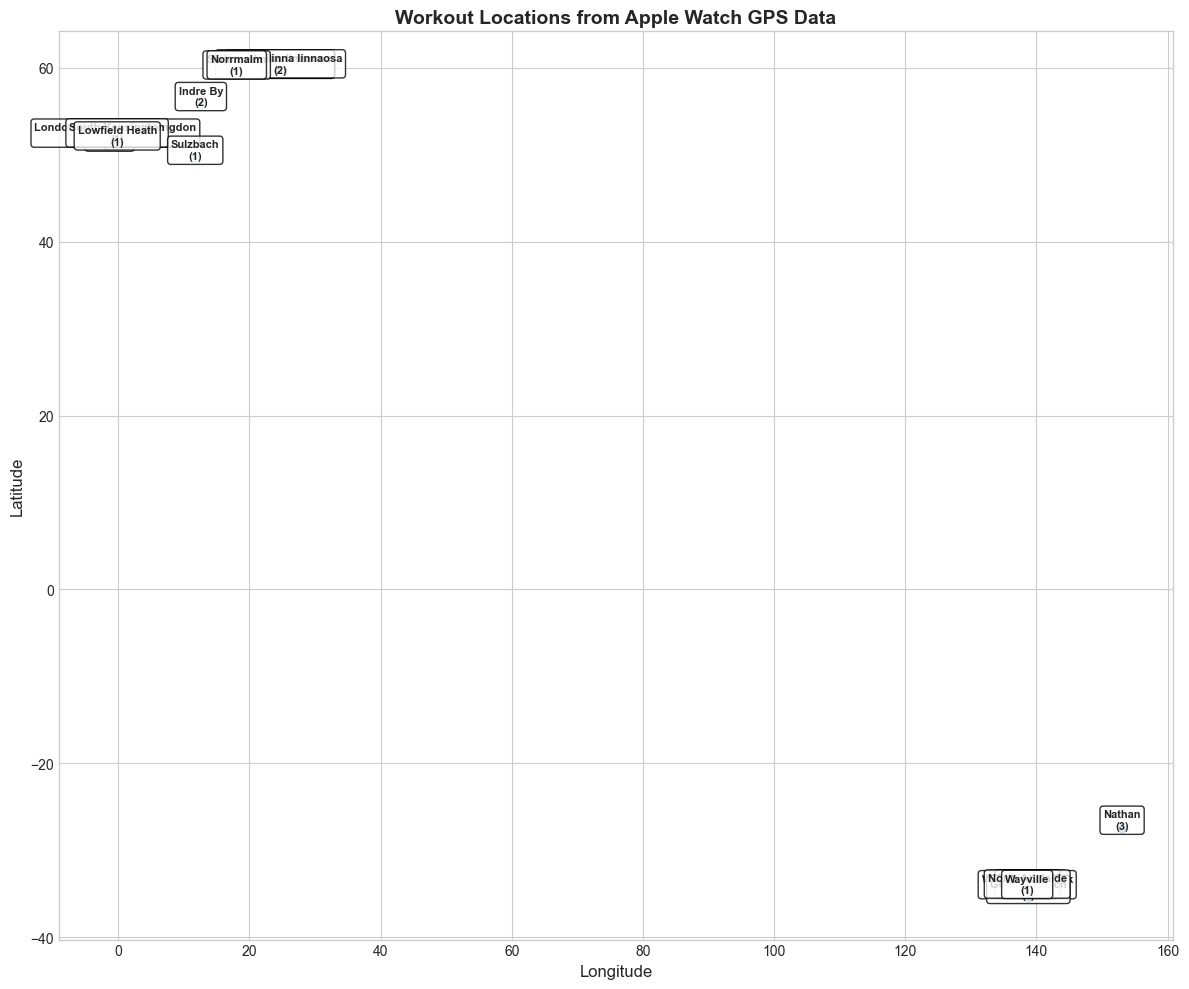

✅ Saved: C:\Project\Apple Health Data\../results/data/workout_locations_map.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 10))scatter = ax.scatter(    routes_df['center_lon'],     routes_df['center_lat'],    c=routes_df['location_cluster'],    cmap='tab20',    alpha=0.6,    s=50,    edgecolors='white',    linewidth=0.5)# Mark cluster centers with location namesfor cluster_id in routes_df['location_cluster'].unique():    cluster_routes = routes_df[routes_df['location_cluster'] == cluster_id]    center_lat = cluster_routes['center_lat'].mean()    center_lon = cluster_routes['center_lon'].mean()    name = cluster_names.get(int(cluster_id), f'C{cluster_id}')    count = len(cluster_routes)        ax.annotate(        f'{name}\n({count})',        (center_lon, center_lat),        fontsize=8,        ha='center',        fontweight='bold',        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)    )ax.set_xlabel('Longitude', fontsize=12)ax.set_ylabel('Latitude', fontsize=12)ax.set_title('Workout Locations from Apple Watch GPS Data', fontsize=14, fontweight='bold')plt.tight_layout()plt.savefig(os.path.join(OUTPUT_DIR, 'workout_locations_map.png'), dpi=150, bbox_inches='tight')plt.show()print(f"✅ Saved: {OUTPUT_DIR}/workout_locations_map.png")

## 16. Visualize HR by Location and Climate

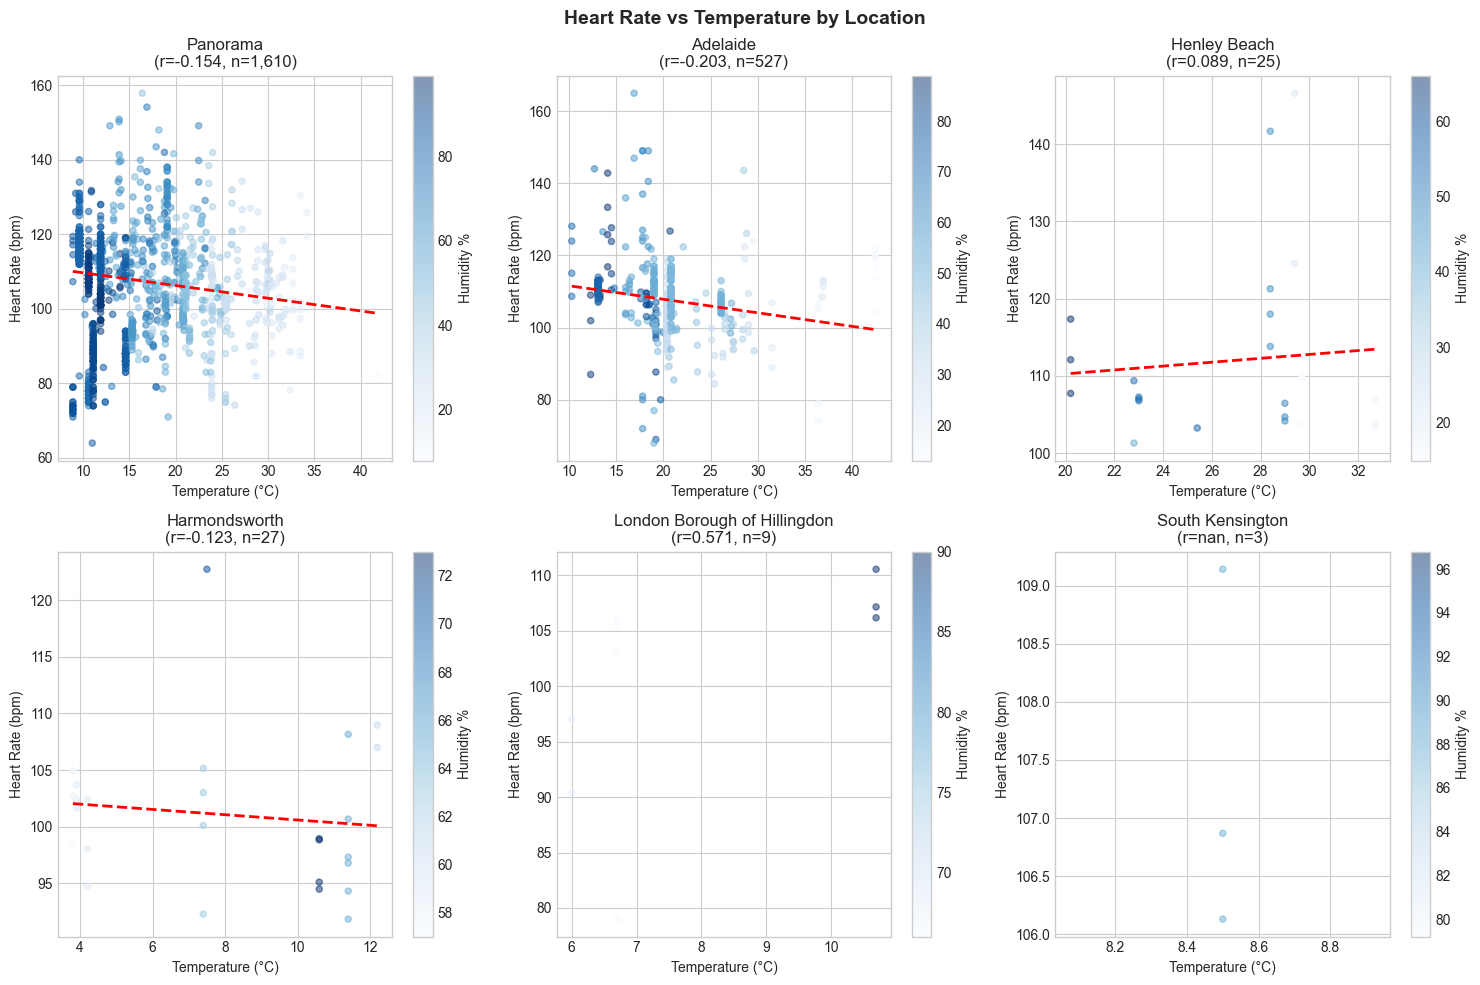

✅ Saved: C:\Project\Apple Health Data\../results/data/hr_temp_by_location.png


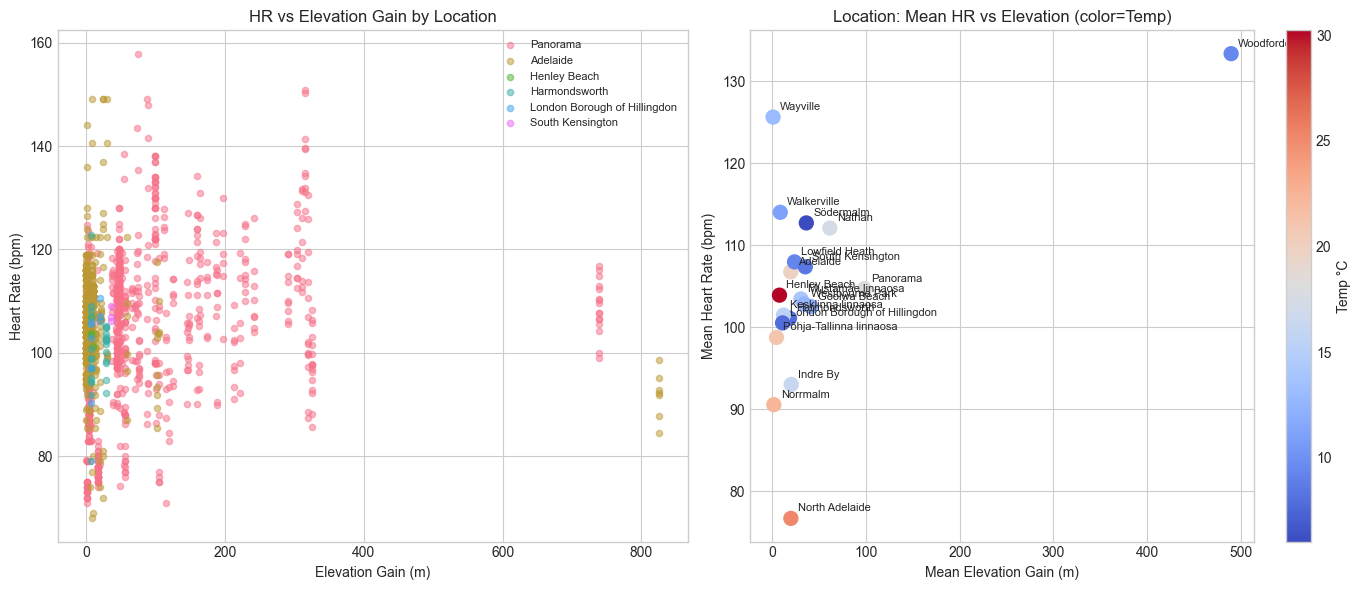

✅ Saved: C:\Project\Apple Health Data\../results/data/hr_elevation_analysis.png


In [18]:
# Plot 1: HR vs Temperature by Locationlocations = workout_weather['location_name'].dropna().unique()n_plots = min(len(locations), 6)fig, axes = plt.subplots(2, 3, figsize=(15, 10))axes = axes.flatten()for i, loc_name in enumerate(locations[:n_plots]):    ax = axes[i]    loc_data = workout_weather[workout_weather['location_name'] == loc_name]        scatter = ax.scatter(        loc_data['temperature_c'],        loc_data['value'],        c=loc_data['humidity_pct'],        cmap='Blues',        alpha=0.5,        s=20    )        if len(loc_data) > 10:        z = np.polyfit(loc_data['temperature_c'], loc_data['value'], 1)        p = np.poly1d(z)        x_line = np.linspace(loc_data['temperature_c'].min(), loc_data['temperature_c'].max(), 100)        ax.plot(x_line, p(x_line), 'r--', linewidth=2)        corr = loc_data['temperature_c'].corr(loc_data['value'])    ax.set_xlabel('Temperature (°C)')    ax.set_ylabel('Heart Rate (bpm)')    ax.set_title(f'{loc_name}\n(r={corr:.3f}, n={len(loc_data):,})')        plt.colorbar(scatter, ax=ax, label='Humidity %')for j in range(n_plots, len(axes)):    axes[j].set_visible(False)plt.suptitle('Heart Rate vs Temperature by Location', fontsize=14, fontweight='bold')plt.tight_layout()plt.savefig(os.path.join(OUTPUT_DIR, 'hr_temp_by_location.png'), dpi=150, bbox_inches='tight')plt.show()print(f"✅ Saved: {OUTPUT_DIR}/hr_temp_by_location.png")# Plot 2: HR vs Elevationfig, axes = plt.subplots(1, 2, figsize=(14, 6))routes_elevation = routes_df[['start_time', 'elevation_gain', 'avg_elevation', 'location_name']].copy()routes_elevation['workout_date'] = pd.to_datetime(routes_elevation['start_time']).dt.dateworkout_weather['workout_date'] = workout_weather['startDate'].dt.dateworkout_with_ele = workout_weather.merge(    routes_elevation[['workout_date', 'elevation_gain', 'avg_elevation', 'location_name']].drop_duplicates(),    on=['workout_date', 'location_name'],  # Match cả location để chính xác hơn    how='left',    suffixes=('', '_route'))with_ele = workout_with_ele[workout_with_ele['elevation_gain'].notna()]# 1. HR vs Elevation Gainax1 = axes[0]for loc in with_ele['location_name'].dropna().unique()[:6]:    loc_data = with_ele[with_ele['location_name'] == loc]    ax1.scatter(loc_data['elevation_gain'], loc_data['value'], alpha=0.5, label=loc, s=20)ax1.set_xlabel('Elevation Gain (m)')ax1.set_ylabel('Heart Rate (bpm)')ax1.set_title('HR vs Elevation Gain by Location')ax1.legend(fontsize=8, loc='best')# 2. Mean HR vs Mean Elevation by Locationax2 = axes[1]loc_ele_stats = with_ele.groupby('location_name').agg({    'value': 'mean',    'elevation_gain': 'mean',    'temperature_c': 'mean'}).dropna()if len(loc_ele_stats) > 0:    scatter = ax2.scatter(        loc_ele_stats['elevation_gain'],        loc_ele_stats['value'],        c=loc_ele_stats['temperature_c'],        cmap='coolwarm',        s=100    )        for loc in loc_ele_stats.index:        ax2.annotate(loc,                      (loc_ele_stats.loc[loc, 'elevation_gain'], loc_ele_stats.loc[loc, 'value']),                      fontsize=8,                     xytext=(5, 5),                     textcoords='offset points')        plt.colorbar(scatter, ax=ax2, label='Temp °C')ax2.set_xlabel('Mean Elevation Gain (m)')ax2.set_ylabel('Mean Heart Rate (bpm)')ax2.set_title('Location: Mean HR vs Elevation (color=Temp)')plt.tight_layout()plt.savefig(os.path.join(OUTPUT_DIR, 'hr_elevation_analysis.png'), dpi=150, bbox_inches='tight')plt.show()print(f"✅ Saved: {OUTPUT_DIR}/hr_elevation_analysis.png")

## 17. Compare HR Across Different Locations

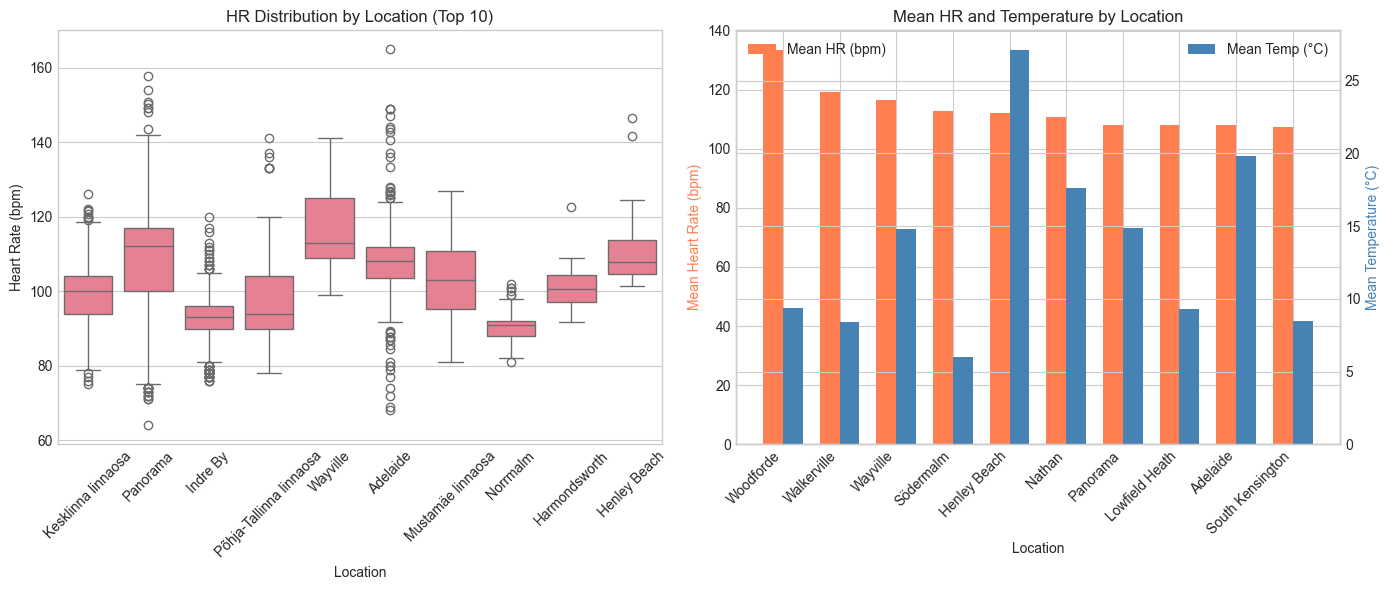

✅ Saved: C:\Project\Apple Health Data\../results/data/hr_comparison_by_location.png
📊 WALKING HR COMPARISON (Fair)

🚶 Walking HR by Location (adjusted for elevation):
                              Count  Mean HR   Std  Temp °C  Elev Gain (m)
location_name                                                             
Wayville                         90    125.7   3.8     13.0            0.7
Nathan                           36    111.3   8.0     17.5           61.3
Lowfield Heath                    6    108.0   4.3      9.3           23.6
Adelaide                        481    106.5   9.3     19.6           20.1
Mustamäe linnaosa               346    103.5  12.2     14.1           30.5
Panorama                        808    103.5  12.1     17.3          117.0
Goolwa Beach                     15    102.5   5.2     11.9           40.9
Harmondsworth                    22    101.1   6.9      8.7           15.9
Kesklinna linnaosa             5176    100.8   6.6     15.0           11.6
London B

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))# 1. Boxplot: HR distribution by locationax1 = axes[0]workout_weather_clean = workout_weather[workout_weather['location_name'].notna()]location_order = workout_weather_clean.groupby('location_name')['value'].count().sort_values(ascending=False).head(10).indexdata_to_plot = workout_weather_clean[workout_weather_clean['location_name'].isin(location_order)].copy()# Sử dụng seaborn cho boxplot đẹp hơn và kiểm soát orderimport seaborn as snssns.boxplot(data=data_to_plot, x='location_name', y='value', order=location_order, ax=ax1)ax1.set_xlabel('Location')ax1.set_ylabel('Heart Rate (bpm)')ax1.set_title('HR Distribution by Location (Top 10)')ax1.tick_params(axis='x', rotation=45)# 2. Bar chart: Mean HR and Temperature by locationax2 = axes[1]loc_stats = workout_weather_clean.groupby('location_name').agg({    'value': 'mean',    'temperature_c': 'mean'}).round(1)loc_stats = loc_stats.sort_values('value', ascending=False).head(10)x = np.arange(len(loc_stats))width = 0.35bars1 = ax2.bar(x - width/2, loc_stats['value'], width, label='Mean HR (bpm)', color='coral')ax2_twin = ax2.twinx()bars2 = ax2_twin.bar(x + width/2, loc_stats['temperature_c'], width, label='Mean Temp (°C)', color='steelblue')ax2.set_xlabel('Location')ax2.set_ylabel('Mean Heart Rate (bpm)', color='coral')ax2_twin.set_ylabel('Mean Temperature (°C)', color='steelblue')ax2.set_title('Mean HR and Temperature by Location')ax2.set_xticks(x)ax2.set_xticklabels(loc_stats.index, rotation=45, ha='right')ax2.legend(loc='upper left')ax2_twin.legend(loc='upper right')plt.tight_layout()plt.savefig(os.path.join(OUTPUT_DIR, 'hr_comparison_by_location.png'), dpi=150, bbox_inches='tight')plt.show()print(f"✅ Saved: {OUTPUT_DIR}/hr_comparison_by_location.png")# Walking analysiswalking_only = workout_with_ele[workout_with_ele['workout_type'] == 'Walking'].copy()print("📊 WALKING HR COMPARISON (Fair)")print("=" * 50)walking_stats = walking_only.groupby('location_name').agg({    'value': ['count', 'mean', 'std'],    'temperature_c': 'mean',    'elevation_gain': 'mean'}).round(1)walking_stats.columns = ['Count', 'Mean HR', 'Std', 'Temp °C', 'Elev Gain (m)']walking_stats = walking_stats[walking_stats['Count'] >= 5].sort_values('Mean HR', ascending=False)print("\n🚶 Walking HR by Location (adjusted for elevation):")print(walking_stats)print(f"\n📈 Walking HR Correlations:")if len(walking_only) > 10:    print(f"   Temperature ↔ HR: {walking_only['temperature_c'].corr(walking_only['value']):.3f}")    print(f"   Elevation Gain ↔ HR: {walking_only['elevation_gain'].corr(walking_only['value']):.3f}")else:    print("   ⚠️ Not enough data for correlations")

## 18. Temporal Analysis by Location

In [20]:
print("📊 TEMPORAL PATTERNS BY LOCATION")print("=" * 60)workout_weather['hour'] = workout_weather['startDate'].dt.hourworkout_weather['month'] = workout_weather['startDate'].dt.monthworkout_weather['season'] = workout_weather['month'].map({    12: 'Summer', 1: 'Summer', 2: 'Summer',    3: 'Autumn', 4: 'Autumn', 5: 'Autumn',    6: 'Winter', 7: 'Winter', 8: 'Winter',    9: 'Spring', 10: 'Spring', 11: 'Spring'})# Seasonal patternsprint("\n🌸 Seasonal HR by Location:")seasonal_stats = workout_weather.groupby(['location_name', 'season']).agg({    'value': ['mean', 'count'],    'temperature_c': 'mean'}).round(1)print(seasonal_stats)# Hourly patternsprint("\n⏰ Peak Workout Hours by Location:")hourly_counts = workout_weather.groupby(['location_name', 'hour']).size().unstack(fill_value=0)print("   Peak hours:")for location in hourly_counts.index:    peak_hour = hourly_counts.loc[location].idxmax()    count = hourly_counts.loc[location].max()    print(f"   {location}: {peak_hour}:00 ({count} records)")

📊 TEMPORAL PATTERNS BY LOCATION

🌸 Seasonal HR by Location:
                                     value       temperature_c
                                      mean count          mean
location_name                season                           
Adelaide                     Autumn  106.4   271          20.8
                             Spring  110.6   121          14.2
                             Summer  107.4   123          23.9
                             Winter  119.7    12          12.3
Goolwa Beach                 Winter  102.5    15          11.9
Harmondsworth                Autumn  101.1    27           7.8
Henley Beach                 Summer  112.1    25          27.1
Indre By                     Winter   93.0  1233          16.2
Kesklinna linnaosa           Autumn  110.2    35           1.2
                             Winter   98.2  1995          15.8
London Borough of Hillingdon Autumn  100.5     9           7.9
Lowfield Heath               Autumn  108.0     6          

## 19. Visualize Seasonal and Hourly Patterns

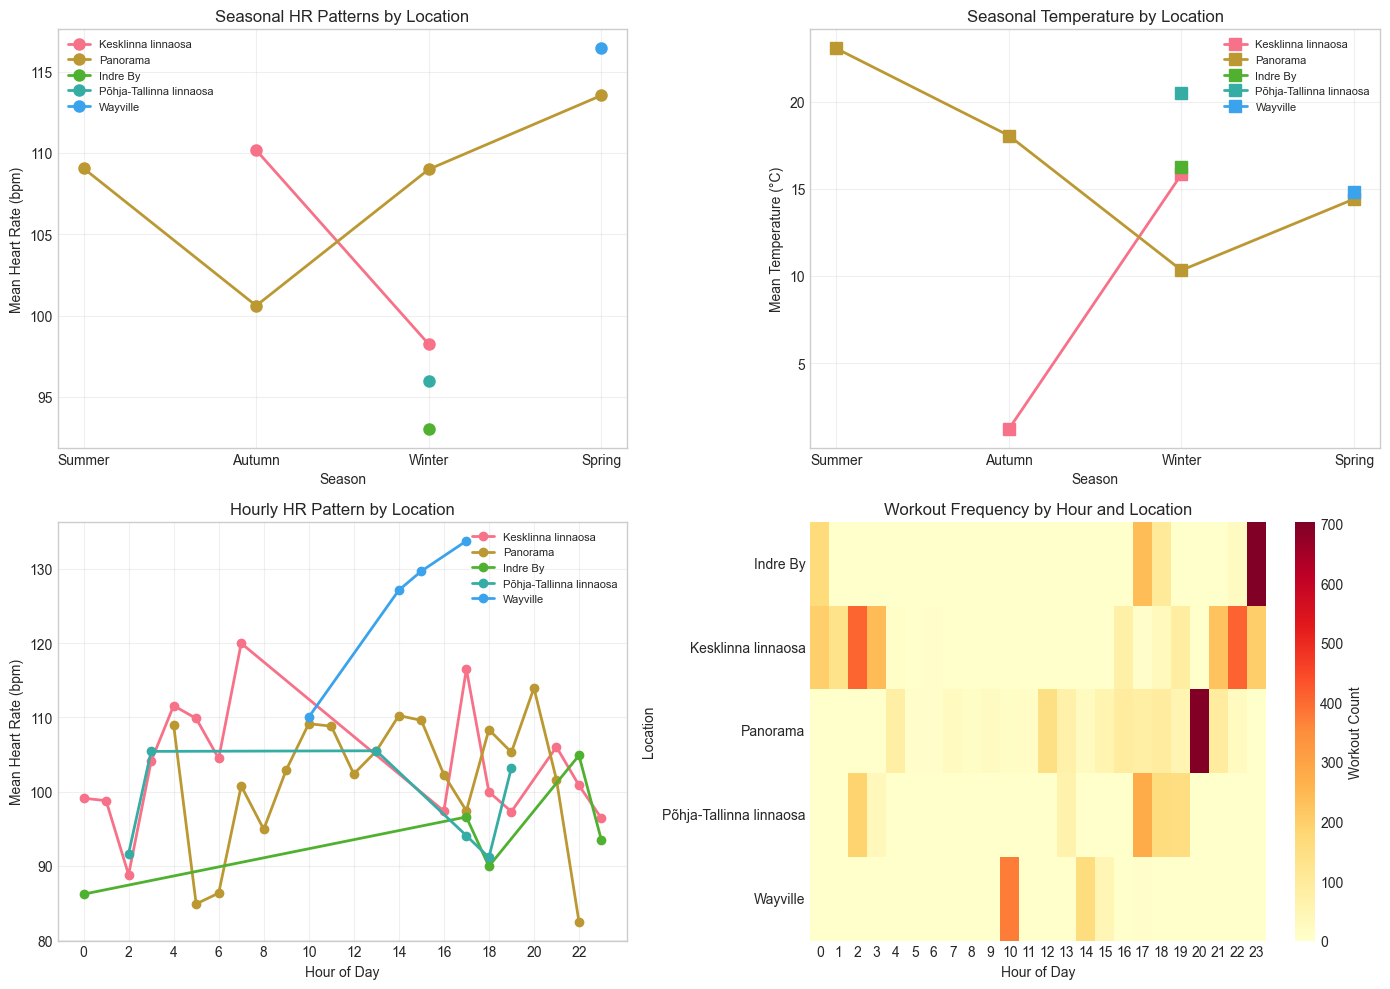

✅ Saved: C:\Project\Apple Health Data\output/temporal_patterns_by_location.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))top_locations = workout_weather['location_name'].dropna().value_counts().head(5).index.tolist()workout_top = workout_weather[workout_weather['location_name'].isin(top_locations)]season_order = ['Summer', 'Autumn', 'Winter', 'Spring']# 1. HR by Season and Locationax1 = axes[0, 0]for loc_name in top_locations:    loc_data = workout_top[workout_top['location_name'] == loc_name]    seasonal_hr = loc_data.groupby('season')['value'].mean().reindex(season_order)    ax1.plot(seasonal_hr.index, seasonal_hr.values, 'o-', label=loc_name, linewidth=2, markersize=8)ax1.set_xlabel('Season')ax1.set_ylabel('Mean Heart Rate (bpm)')ax1.set_title('Seasonal HR Patterns by Location')ax1.legend(fontsize=8, loc='best')ax1.grid(True, alpha=0.3)# 2. Temperature by Season and Location  ax2 = axes[0, 1]for loc_name in top_locations:    loc_data = workout_top[workout_top['location_name'] == loc_name]    seasonal_temp = loc_data.groupby('season')['temperature_c'].mean().reindex(season_order)    ax2.plot(seasonal_temp.index, seasonal_temp.values, 's-', label=loc_name, linewidth=2, markersize=8)ax2.set_xlabel('Season')ax2.set_ylabel('Mean Temperature (°C)')ax2.set_title('Seasonal Temperature by Location')ax2.legend(fontsize=8, loc='best')ax2.grid(True, alpha=0.3)# 3. Hourly HR Patternax3 = axes[1, 0]for loc_name in top_locations:    loc_data = workout_top[workout_top['location_name'] == loc_name]    hourly_hr = loc_data.groupby('hour')['value'].mean()    ax3.plot(hourly_hr.index, hourly_hr.values, 'o-', label=loc_name, linewidth=2)ax3.set_xlabel('Hour of Day')ax3.set_ylabel('Mean Heart Rate (bpm)')ax3.set_title('Hourly HR Pattern by Location')ax3.set_xticks(range(0, 24, 2))ax3.legend(fontsize=8, loc='best')ax3.grid(True, alpha=0.3)# 4. Workout Frequency Heatmapax4 = axes[1, 1]pivot = workout_top.groupby(['location_name', 'hour']).size().unstack(fill_value=0)if len(pivot) > 0:    sns.heatmap(pivot, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Workout Count'})ax4.set_xlabel('Hour of Day')ax4.set_ylabel('Location')ax4.set_title('Workout Frequency by Hour and Location')plt.tight_layout()plt.savefig(os.path.join(OUTPUT_DIR, 'temporal_patterns_by_location.png'), dpi=150, bbox_inches='tight')plt.show()print(f"✅ Saved: {OUTPUT_DIR}/temporal_patterns_by_location.png")

## 20. Final Summary Report

In [22]:
print("\n" + "="*70)print("📊 FINAL SUMMARY: HR vs LOCATION & CLIMATE ANALYSIS")print("="*70)print(f"""📁 DATA OVERVIEW:   - Total HR records: {len(hr_df):,}   - Workout HR records: {len(hr_df[hr_df['activity_context'] == 'workout']):,}   - HR with location data: {hr_df['location_cluster'].notna().sum():,}   - Date range: {hr_df['startDate'].min().date()} → {hr_df['startDate'].max().date()}📍 LOCATION ANALYSIS:   - GPX routes parsed: {len(routes_df)}   - Distinct workout locations: {len(cluster_names)}""")print("💓 HR BY LOCATION:")for loc_name in workout_weather['location_name'].dropna().unique():    loc_data = workout_weather[workout_weather['location_name'] == loc_name]    if len(loc_data) < 10:        continue        print(f"""   📍 {loc_name}:      HR records: {len(loc_data):,}      Mean HR: {loc_data['value'].mean():.1f} bpm      Temp range: {loc_data['temperature_c'].min():.1f}°C - {loc_data['temperature_c'].max():.1f}°C      Temp↔HR correlation: {loc_data['temperature_c'].corr(loc_data['value']):.3f}""")print(f"""📂 OUTPUT FILES:   - {OUTPUT_DIR}/workout_locations_map.png   - {OUTPUT_DIR}/hr_temp_by_location.png   - {OUTPUT_DIR}/hr_comparison_by_location.png   - {OUTPUT_DIR}/temporal_patterns_by_location.png""")


📊 FINAL SUMMARY: HR vs LOCATION & CLIMATE ANALYSIS

📁 DATA OVERVIEW:
   - Total HR records: 360,282
   - Workout HR records: 8,285
   - HR with location data: 5,073
   - Date range: 2017-11-27 → 2022-09-23

📍 LOCATION ANALYSIS:
   - GPX routes parsed: 177
   - Distinct workout locations: 23

💓 HR BY LOCATION:

   📍 Panorama:
      HR records: 1,610
      Mean HR: 108.0 bpm
      Temp range: 8.9°C - 41.8°C
      Temp↔HR correlation: -0.154


   📍 Adelaide:
      HR records: 527
      Mean HR: 107.9 bpm
      Temp range: 10.3°C - 42.5°C
      Temp↔HR correlation: -0.203


   📍 Henley Beach:
      HR records: 25
      Mean HR: 112.1 bpm
      Temp range: 20.2°C - 32.7°C
      Temp↔HR correlation: 0.089


   📍 Harmondsworth:
      HR records: 27
      Mean HR: 101.1 bpm
      Temp range: 3.8°C - 12.2°C
      Temp↔HR correlation: -0.123


   📍 Kesklinna linnaosa:
      HR records: 2,030
      Mean HR: 98.4 bpm
      Temp range: -1.5°C - 20.8°C
      Temp↔HR correlation: 0.007


   📍 Woodfo

## 21. Export Data for Further Analysis

In [23]:
# Save enriched datahr_with_weather.to_csv(os.path.join(OUTPUT_DIR, 'hr_with_location_weather.csv'), index=False)routes_df.to_csv(os.path.join(OUTPUT_DIR, 'workout_routes.csv'), index=False)location_summary.to_csv(os.path.join(OUTPUT_DIR, 'location_summary.csv'))print("✅ Exported:")print(f"   - {OUTPUT_DIR}/hr_with_location_weather.csv")print(f"   - {OUTPUT_DIR}/workout_routes.csv")print(f"   - {OUTPUT_DIR}/location_summary.csv")

✅ Exported:
   - C:\Project\Apple Health Data\../results/data/hr_with_location_weather.csv
   - C:\Project\Apple Health Data\../results/data/workout_routes.csv
   - C:\Project\Apple Health Data\../results/data/location_summary.csv
